# Dark Pattern Detector — Notebook 2: Modeling, Tuning & Export

**Goal:** train classical ML models on the features from Notebook 1, pick the best one,
tune it, evaluate it on unseen data, and export it for the Streamlit app.

Steps:
1. Load the processed features.
2. Define features / targets and split off a held out test set.
3. Build the TF-IDF + scaling preprocessing.
4. Compare 5 models with 5-fold cross-validation (SMOTE inside each fold).
5. Tune the best model with Optuna.
6. Evaluate on the held-out test set.
7. Train a binary violation model.
8. Export the final models.

## 1. Importing Libraries

In [59]:
import numpy as np
import pandas as pd
import joblib
import optuna
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, PowerTransformer, MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Load Processed Features

In [60]:
# from notebook 1
df = pd.read_csv('../data/processed/features.csv')
df.head()

,page_id,text,clean_text,label,Pattern Category,urgency_kw_count,scarcity_kw_count,shame_phrase_flag,cancel_diff_score,social_proof_flag,...,word_count,number_present,time_reference_flag,noun_ratio,verb_ratio,adj_ratio,adv_ratio,sentiment_polarity,sentiment_subjectivity,avg_word_len
0,1012,FLASH SALE | LIMITED TIME ONLY Shop Now,flash sale limited time only shop now,1,False Urgency,2,0,0,0,0,...,8,0,0,0.375000,0.125000,0.125000,0.375000,-0.035714,0.571429,4.000000
1,158,Pillowcases & Shams,pillowcase sham,0,Not a Dark Pattern,0,0,0,0,0,...,3,0,0,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,5.666667
2,108,Write a review,write a review,0,Not a Dark Pattern,0,0,0,0,0,...,3,0,0,0.333333,0.333333,0.000000,0.000000,0.000000,0.000000,4.000000
3,1425,"To start your return, simply click on the foll...",to start your return simply click on the follo...,0,Not a Dark Pattern,0,0,0,0,0,...,37,0,0,0.227273,0.159091,0.022727,0.045455,0.133333,0.452381,4.729730
4,1658,newsletter signup (privacy policy),newsletter signup privacy policy,0,Not a Dark Pattern,0,0,0,0,0,...,4,0,0,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,7.750000


In [61]:
df.isnull().sum()

page_id                   0
text                      0
clean_text                4
label                     0
Pattern Category          0
urgency_kw_count          0
scarcity_kw_count         0
shame_phrase_flag         0
cancel_diff_score         0
social_proof_flag         0
price_drip_flag           0
discount_claim_flag       0
neg_option_flag           0
all_caps_ratio            0
exclamation_count         0
question_count            0
text_length               0
word_count                0
number_present            0
time_reference_flag       0
noun_ratio                0
verb_ratio                0
adj_ratio                 0
adv_ratio                 0
sentiment_polarity        0
sentiment_subjectivity    0
avg_word_len              0
dtype: int64

In [62]:
# how many rows do we have..
print(df.shape)

#how much rows we have for each of the classes
df['Pattern Category'].value_counts()

(6716, 27)


Pattern Category
Not a Dark Pattern         2059
False Urgency               782
Disguised Advertisement     607
Interface Interference      362
Confirm Shaming             332
Basket Sneaking             297
Drip Pricing                297
Subscription Trap           292
SaaS Billing                291
Trick Question              290
Forced Action               286
Bait and Switch             286
Nagging                     282
Rogue Malware               253
Name: count, dtype: int64

In [63]:
df['clean_text'].duplicated().value_counts()

clean_text
False    5058
True     1658
Name: count, dtype: int64

In [64]:
df=df.drop_duplicates(subset=['clean_text', 'Pattern Category'])

In [67]:
df['clean_text'] = df['clean_text'].fillna('').astype(str)

## 3. Define Features and Targets

In [68]:
# nuemrical feature columns produced in Notebook 1
num_cols = [
    "urgency_kw_count", "scarcity_kw_count", "shame_phrase_flag", "cancel_diff_score",
    "social_proof_flag", "price_drip_flag", "discount_claim_flag", "neg_option_flag",
    "all_caps_ratio", "exclamation_count", "question_count", "text_length", "word_count",
    "number_present", "time_reference_flag", "noun_ratio", "verb_ratio", "adj_ratio",
    "adv_ratio", "sentiment_polarity", "sentiment_subjectivity", "avg_word_len"
]

# X = clean text + numeric features
X = df[['clean_text'] + num_cols]

#Two targets: 14-class and binary
y_multi = df['Pattern Category']
y_binary = df['label']

In [69]:
y_multi.unique()

<ArrowStringArray>
[          'False Urgency',      'Not a Dark Pattern',
  'Interface Interference', 'Disguised Advertisement',
         'Confirm Shaming',          'Trick Question',
       'Subscription Trap',         'Basket Sneaking',
            'Drip Pricing',           'Forced Action',
           'Rogue Malware',                 'Nagging',
         'Bait and Switch',            'SaaS Billing']
Length: 14, dtype: str

In [70]:
# XGBoost needs integer class labels, so encode the 14 category names
le = LabelEncoder()
y = le.fit_transform(y_multi)
list(le.classes_)

['Bait and Switch',
 'Basket Sneaking',
 'Confirm Shaming',
 'Disguised Advertisement',
 'Drip Pricing',
 'False Urgency',
 'Forced Action',
 'Interface Interference',
 'Nagging',
 'Not a Dark Pattern',
 'Rogue Malware',
 'SaaS Billing',
 'Subscription Trap',
 'Trick Question']

## 4. Train / Test Split (held out first)

We carve off 20% as a **held-out test set right now**, before any balancing or tuning.
The model never sees it during training, so the final score is honest.

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , stratify=y, random_state=42)
print(X_train.shape)
print(X_test.shape)

(4048, 23)
(1013, 23)


## 5. Preprocessing: TF-IDF + Scaling

A ColumnTransformer runs TF-IDF on the text column and scales the numeric features.
We make two versions: a standard one (RobustScaler + Yeo-Johnson) and a MinMax one for
Naive Bayes, which cannot take negative inputs.

In [73]:
preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(max_features=300, ngram_range=(1, 3), min_df=2, sublinear_tf=True), 'clean_text'),
    ('num', Pipeline([('scale', RobustScaler()), ('power', PowerTransformer(method='yeo-johnson'))]), num_cols),
])

preprocessor_nb = ColumnTransformer([
    ('text', TfidfVectorizer(max_features=300, ngram_range=(1, 3), min_df=2, sublinear_tf=True), 'clean_text'),
    ('num', MinMaxScaler(), num_cols),
])

## 6. Why SMOTE Inside the Cross-Validation Folds

Classes are imbalanced, so we oversample the minority classes with SMOTE. But SMOTE must
run **only on the training part of each fold** - if we balanced the whole dataset first,
synthetic points built from test rows would leak in. Using `imblearn`'s Pipeline puts
SMOTE inside the fold automatically. We also score with **macro-F1**, which weighs every
class equally (accuracy would let the model ignore the rare classes).

## 7. Compare 5 Models with 5-Fold CV

In [74]:
# Each model is an imblearn pipeline: preprocess -> SMOTE -> classifier
models = {
    "Logistic Regression": ImbPipeline([('prep', preprocessor), #('smote', SMOTE(random_state=42)),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))]),

    "Linear SVC": ImbPipeline([('prep', preprocessor), ('smote', SMOTE(random_state=42)),
        ('clf', LinearSVC( random_state=42))]),

    "Complement NB": ImbPipeline([('prep', preprocessor_nb), #('smote', SMOTE(random_state=42)),
        ('clf', ComplementNB())]),

    "Random Forest": ImbPipeline([('prep', preprocessor), ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]),

    "XGBoost": ImbPipeline([('prep', preprocessor), ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(eval_metric='mlogloss', random_state=42, tree_method='hist'))]),
}

In [75]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["f1_macro", "f1_weighted", "accuracy"]
results = []

for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    metrics = {"Model": name}
    for score in scoring:
        metrics[f"{score}_mean"] = res[f"test_{score}"].mean()
        metrics[f"{score}_std"] = res[f"test_{score}"].std()
    results.append(metrics)

df_res = pd.DataFrame(results).set_index("Model")
print(df_res.round(4))

                     f1_macro_mean  f1_macro_std  f1_weighted_mean  \
Model                                                                
Logistic Regression         0.9131        0.0061            0.9082   
Linear SVC                  0.9458        0.0046            0.9389   
Complement NB               0.8293        0.0200            0.8483   
Random Forest               0.9621        0.0087            0.9559   
XGBoost                     0.9514        0.0098            0.9472   

                     f1_weighted_std  accuracy_mean  accuracy_std  
Model                                                              
Logistic Regression           0.0083         0.9083        0.0082  
Linear SVC                    0.0078         0.9390        0.0078  
Complement NB                 0.0081         0.8483        0.0080  
Random Forest                 0.0068         0.9563        0.0068  
XGBoost                       0.0082         0.9476        0.0081  


## 8. Tune XGBoost with Optuna

Optuna searches the hyperparameter space using Bayesian optimization. The objective is the
**cross-validated macro-F1 on the training data only** - the test set stays untouched.

In [88]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [89]:
for fold, (tr, va) in enumerate(cv.split(X_train, y_train), 1):
    print(f"Fold {fold}: train={len(tr)}, valid={len(va)}")

Fold 1: train=3238, valid=810
Fold 2: train=3238, valid=810
Fold 3: train=3238, valid=810
Fold 4: train=3239, valid=809
Fold 5: train=3239, valid=809


In [90]:
def objective_svc(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 50, log=True),
        'loss': trial.suggest_categorical('loss', ['hinge', 'squared_hinge']),
    }
    pipe = ImbPipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', LinearSVC(**params, class_weight='balanced', random_state=42, max_iter=5000))
    ])
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', error_score='raise').mean()

In [91]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 350),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
    }
    pipe = ImbPipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(**params, eval_metric='mlogloss', random_state=42, tree_method='hist'))
    ])
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', error_score='raise').mean()

In [ ]:
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=12)

study_svc = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_svc.optimize(objective_svc, n_trials=12)

print("Best XGB CV macro-F1:", round(study_xgb.best_value, 4), study_xgb.best_params)
print("Best SVC CV macro-F1:", round(study_svc.best_value, 4), study_svc.best_params)

## 9. Evaluate the Tuned Model on the Held-out Test Set

In [ ]:
# fit the tuned model on all of training data
best = ImbPipeline([('prep', preprocessor), ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(**study.best_params, eval_metric='mlogloss', random_state=42, tree_method='hist'))])
best.fit(X_train, y_train)

#, predict on untouched test set
pred = best.predict(X_test)

print("Test accuracy :", round(accuracy_score(y_test, pred), 4))
print("Test macro-F1 :", round(f1_score(y_test, pred, average='macro'), 4))

Test accuracy : 0.9714
Test macro-F1 : 0.9708


In [13]:
# Full per-class report (precision / recall / F1)
print(classification_report(y_test, pred, target_names=le.classes_, zero_division=0))

                         precision    recall  f1-score   support

        Bait and Switch       0.98      1.00      0.99        58
        Basket Sneaking       1.00      0.96      0.98        47
        Confirm Shaming       0.96      1.00      0.98        43
Disguised Advertisement       0.92      0.97      0.94        62
           Drip Pricing       1.00      1.00      1.00        61
          False Urgency       0.96      0.94      0.95        98
          Forced Action       1.00      0.93      0.97        61
 Interface Interference       0.96      0.88      0.91        73
                Nagging       1.00      1.00      1.00        39
     Not a Dark Pattern       0.96      0.99      0.97       351
          Rogue Malware       0.97      1.00      0.98        32
           SaaS Billing       1.00      1.00      1.00        76
      Subscription Trap       1.00      1.00      1.00        65
         Trick Question       1.00      0.84      0.91        19

               accuracy

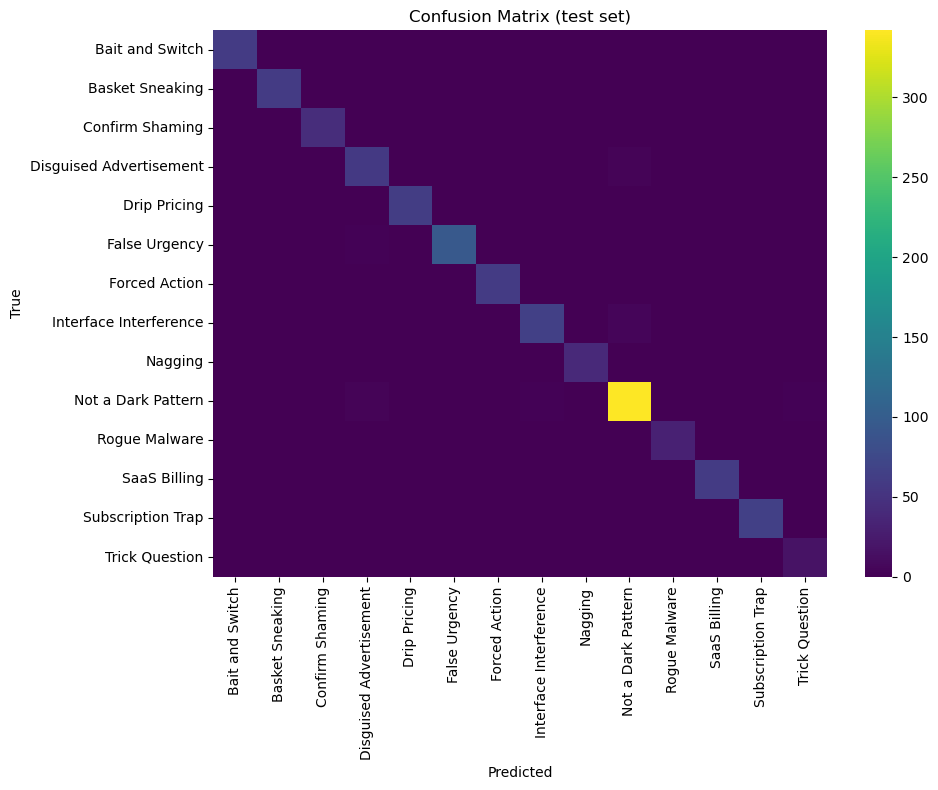

In [14]:
# Confusion matrix on the test set
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(cm, annot=False, cmap='viridis', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (test set)')
plt.tight_layout()
plt.show()

## 10. Binary Violation Model

In [14]:
# A simpler model that just answers "is this a dark pattern? yes/no"
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X, y_binary, test_size=0.20, stratify=y_binary, random_state=42)

bin_model = ImbPipeline([('prep', preprocessor_std), ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(n_estimators=300, max_depth=6, eval_metric='logloss', random_state=42, tree_method='hist'))])
bin_model.fit(Xb_tr, yb_tr)
print(classification_report(yb_te, bin_model.predict(Xb_te), zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       351
           1       0.99      0.98      0.98       734

    accuracy                           0.98      1085
   macro avg       0.97      0.97      0.97      1085
weighted avg       0.98      0.98      0.98      1085



## 11. Export the Final Models

We refit on the **entire** dataset (now that evaluation is done) so the deployed model uses
every example, then save the pipelines and the label encoder for the Streamlit app.

In [15]:
# Refit on all data and save
best.fit(X, y)
bin_model.fit(X, y_binary)

joblib.dump(best, '../models/best_multi_model.joblib')
joblib.dump(bin_model, '../models/best_binary_model.joblib')
joblib.dump(le, '../models/label_encoder.joblib')
print("Saved best_multi_model, best_binary_model and label_encoder to ../models/")

Saved best_multi_model, best_binary_model and label_encoder to ../models/
